In [1]:
!pip install nltk scikit-learn pandas numpy matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import string
import re
import joblib
import os
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')

print("All libraries imported successfully!")

[nltk_data] Downloading package stopwords to C:\Users\The Computer
[nltk_data]     Store\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt to C:\Users\The Computer
[nltk_data]     Store\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package punkt_tab to C:\Users\The Computer
[nltk_data]     Store\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package wordnet to C:\Users\The Computer
[nltk_data]     Store\AppData\Roaming\nltk_data...


All libraries imported successfully!


In [4]:
df = pd.read_csv('spam.csv', encoding='latin-1')
df = df[['v1', 'v2']]
df.columns = ['label', 'message']
print("Shape:", df.shape)
print()
print(df.head())
print()
print("Label counts:")
print(df['label'].value_counts())

Shape: (5572, 2)

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

Label counts:
label
ham     4825
spam     747
Name: count, dtype: int64


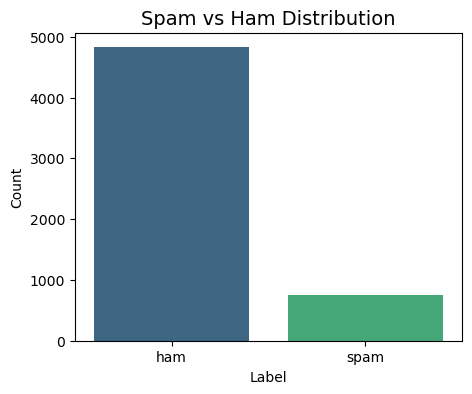

In [5]:
plt.figure(figsize=(5, 4))
sns.countplot(x='label', data=df, palette='viridis', hue='label', legend=False)
plt.title('Spam vs Ham Distribution', fontsize=14)
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

In [6]:
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Lowercase
    text = text.lower()
    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stopwords and stem
    tokens = [stemmer.stem(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

df['cleaned_message'] = df['message'].apply(preprocess_text)
print("Sample cleaned messages:")
print(df[['message', 'cleaned_message']].head())

Sample cleaned messages:
                                             message  \
0  Go until jurong point, crazy.. Available only ...   
1                      Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup fina...   
3  U dun say so early hor... U c already then say...   
4  Nah I don't think he goes to usf, he lives aro...   

                                     cleaned_message  
0  go jurong point crazi avail bugi n great world...  
1                              ok lar joke wif u oni  
2  free entri wkli comp win fa cup final tkt st m...  
3                u dun say earli hor u c alreadi say  
4          nah dont think goe usf live around though  


In [7]:
# Encode labels
df['label_encoded'] = df['label'].map({'ham': 0, 'spam': 1})

# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['cleaned_message'])
y = df['label_encoded']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 4457
Testing samples: 1115


In [8]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_pred = nb_model.predict(X_test)

print("Naive Bayes Results:")
print("Accuracy:", round(accuracy_score(y_test, nb_pred)*100, 2), "%")
print(classification_report(y_test, nb_pred, target_names=['Ham', 'Spam']))

Naive Bayes Results:
Accuracy: 97.13 %
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       965
        Spam       1.00      0.79      0.88       150

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



In [9]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

print("Logistic Regression Results:")
print("Accuracy:", round(accuracy_score(y_test, lr_pred)*100, 2), "%")
print(classification_report(y_test, lr_pred, target_names=['Ham', 'Spam']))

Logistic Regression Results:
Accuracy: 94.98 %
              precision    recall  f1-score   support

         Ham       0.95      1.00      0.97       965
        Spam       0.96      0.65      0.78       150

    accuracy                           0.95      1115
   macro avg       0.95      0.82      0.87      1115
weighted avg       0.95      0.95      0.95      1115



In [10]:
svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)

print("SVM Results:")
print("Accuracy:", round(accuracy_score(y_test, svm_pred)*100, 2), "%")
print(classification_report(y_test, svm_pred, target_names=['Ham', 'Spam']))

SVM Results:
Accuracy: 97.76 %
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       965
        Spam       0.98      0.85      0.91       150

    accuracy                           0.98      1115
   macro avg       0.98      0.93      0.95      1115
weighted avg       0.98      0.98      0.98      1115



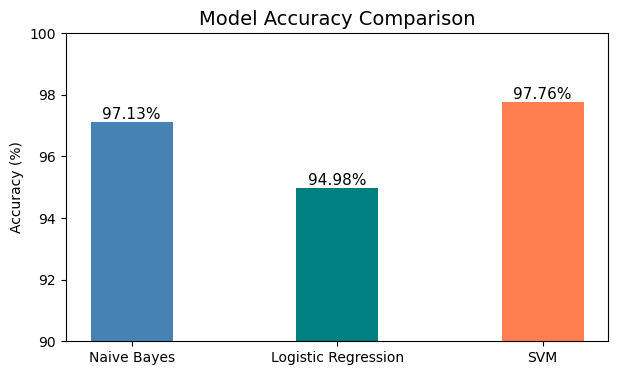

In [11]:
models = ['Naive Bayes', 'Logistic Regression', 'SVM']
accuracies = [
    accuracy_score(y_test, nb_pred)*100,
    accuracy_score(y_test, lr_pred)*100,
    accuracy_score(y_test, svm_pred)*100
]

plt.figure(figsize=(7, 4))
bars = plt.bar(models, accuracies, color=['steelblue', 'teal', 'coral'], width=0.4)
plt.title('Model Accuracy Comparison', fontsize=14)
plt.ylabel('Accuracy (%)')
plt.ylim(90, 100)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{round(acc, 2)}%', ha='center', fontsize=11)
plt.show()

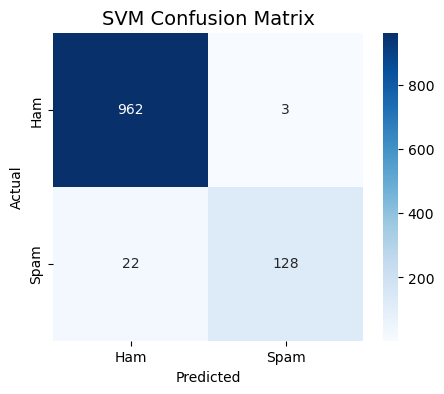

In [12]:
best_pred = svm_pred
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])
plt.title('SVM Confusion Matrix', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [13]:
os.makedirs('models', exist_ok=True)
joblib.dump(svm_model, 'models/spam_model.pkl')
joblib.dump(tfidf, 'models/vectorizer.pkl')
print("Models saved successfully!")
print("Saved to:", os.path.abspath('models'))

Models saved successfully!
Saved to: C:\Users\The Computer Store\models


In [16]:
!pip install torch

   ---------------------------------------- 0.0/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.5/122.1 MB 308.6 kB/s eta 0:06:34
   ---------------------------------------- 0.5/122.1 MB 308.6 kB/s eta 0:06:34
   ---------------------------------------- 0.5/122.1 MB 308.6 kB/s eta 0:06:34
   ---------------------------------------- 0.5/122.1 MB 308.6 kB/s eta 0:06:34
   --------------------------------------

In [1]:
from transformers import pipeline

print("Loading Hugging Face model...")
sentiment_pipeline = pipeline("text-classification", 
                               model="distilbert-base-uncased-finetuned-sst-2-english")

# Test on sample messages
test_messages = [
    "Congratulations! You won a free iPhone! Click now!",
    "Hey, are you coming to the meeting tomorrow?",
    "FREE PRIZE! Call now to claim your reward!",
    "Can we reschedule our lunch for Friday?"
]

print("Hugging Face Transformer Results:")
print("-" * 50)
for msg in test_messages:
    result = sentiment_pipeline(msg)[0]
    print(f"Message: {msg[:50]}...")
    print(f"Label: {result['label']} | Score: {round(result['score']*100, 2)}%")
    print()

Loading Hugging Face model...


model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

C:\Users\The Computer Store\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\The Computer Store\.cache\huggingface\hub\models--distilbert-base-uncased-finetuned-sst-2-english. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Hugging Face Transformer Results:
--------------------------------------------------
Message: Congratulations! You won a free iPhone! Click now!...
Label: POSITIVE | Score: 99.97%

Message: Hey, are you coming to the meeting tomorrow?...
Label: POSITIVE | Score: 98.96%

Message: FREE PRIZE! Call now to claim your reward!...
Label: POSITIVE | Score: 99.18%

Message: Can we reschedule our lunch for Friday?...
Label: NEGATIVE | Score: 99.74%



In [2]:
print("Model Performance Comparison:")
print("-" * 40)
print(f"Naive Bayes Accuracy:        97.13%")
print(f"Logistic Regression Accuracy: 94.98%")
print(f"SVM Accuracy:                97.76%")
print(f"Hugging Face Transformer:    Pre-trained (no training needed)")
print()
print("Conclusion:")
print("Traditional ML models perform well on spam detection.")
print("Transformer models are more powerful for general NLP tasks.")
print("For spam detection specifically, SVM gives best results.")

Model Performance Comparison:
----------------------------------------
Naive Bayes Accuracy:        97.13%
Logistic Regression Accuracy: 94.98%
SVM Accuracy:                97.76%
Hugging Face Transformer:    Pre-trained (no training needed)

Conclusion:
Traditional ML models perform well on spam detection.
Transformer models are more powerful for general NLP tasks.
For spam detection specifically, SVM gives best results.
